# **Decision Tree**

A decision tree is a **supervised learning algorithm** used for classification and regression. Makes predictions by asking a series of yes/no questions about features in your data. At each internal node, it splits on a feature that best separates the data; at the leaves, it gives a final prediction.

 ## **How does the decision tree work?**

The tree starts with all training samples at the root. It then searches every feature and every possible threshold value to find the single split that best separates the data. "Best" is measured by a purity criterion:

* **Gini impurity** — measures the probability that a randomly chosen sample would be
misclassified. A node is pure (Gini = 0) when all its samples belong to one class.

$$ Gini = 1−∑pi2^​ $$

* **Information gain (Entropy)** — measures how much uncertainty is reduced by a split, borrowed from information theory.

$$ Entropy = −∑pi​log_2​(pi​) $$

## **When should this algorithm be used?**

* Interpretability is required
* Your data has a mix of feature types
* Non-linear relationships exist
* You want a fast baseline

## **Advantages and limitations**

Advantages:
* easy to understand.
* Handles mixed types.
* No heavy preprocessing.
* Handles nonlinear data.


Limitations:
* Prone to overfitting.
* High variance.
* Bias toward dominant features.
* Weak standalone predictor.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

#Heart Disease Prediction Dataset

This dataset contains 1,888 records merged from five publicly available heart disease datasets. It includes 14 features that are crucial for predicting heart attack and stroke risks, covering both medical and demographic factors. Below is a detailed description of each feature.
[DataSet](https://www.kaggle.com/datasets/mfarhaannazirkhan/heart-dataset)

In [22]:
df = pd.read_csv('/content/raw_merged_heart_dataset.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df = pd.read_csv('/content/archive (2).zip')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Exploratory Data Analysis (EDA)

Explore the dataset structure

Identify features and target variable

Visualize important relationships

Check for missing values

Examples of visualizations:
Histograms

Correlation heatmap

Bar plots

Count plots

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2181 non-null   int64  
 1   sex       2181 non-null   int64  
 2   cp        2181 non-null   int64  
 3   trestbps  2181 non-null   object 
 4   chol      2181 non-null   object 
 5   fbs       2181 non-null   object 
 6   restecg   2181 non-null   object 
 7   thalachh  2181 non-null   object 
 8   exang     2181 non-null   object 
 9   oldpeak   2181 non-null   float64
 10  slope     2181 non-null   object 
 11  ca        2181 non-null   object 
 12  thal      2181 non-null   object 
 13  target    2181 non-null   int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 238.7+ KB


In [24]:
df.describe()

,age,sex,cp,oldpeak,target
count,2181.000000,2181.000000,2181.000000,2181.000000,2181.000000
mean,53.477762,0.693260,1.248968,0.990509,0.496103
std,9.194787,0.461246,1.123520,1.141851,0.500099
min,28.000000,0.000000,0.000000,0.000000,0.000000
25%,46.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,1.000000,0.600000,0.000000
75%,60.000000,1.000000,2.000000,1.600000,1.000000
max,77.000000,1.000000,3.000000,6.200000,1.000000


**Features:** age, sex, cp, trestbps, chol, fbs, restecg, thalachh,
       exang, oldpeak, slope, ca, thal,

**Target Variable:** target

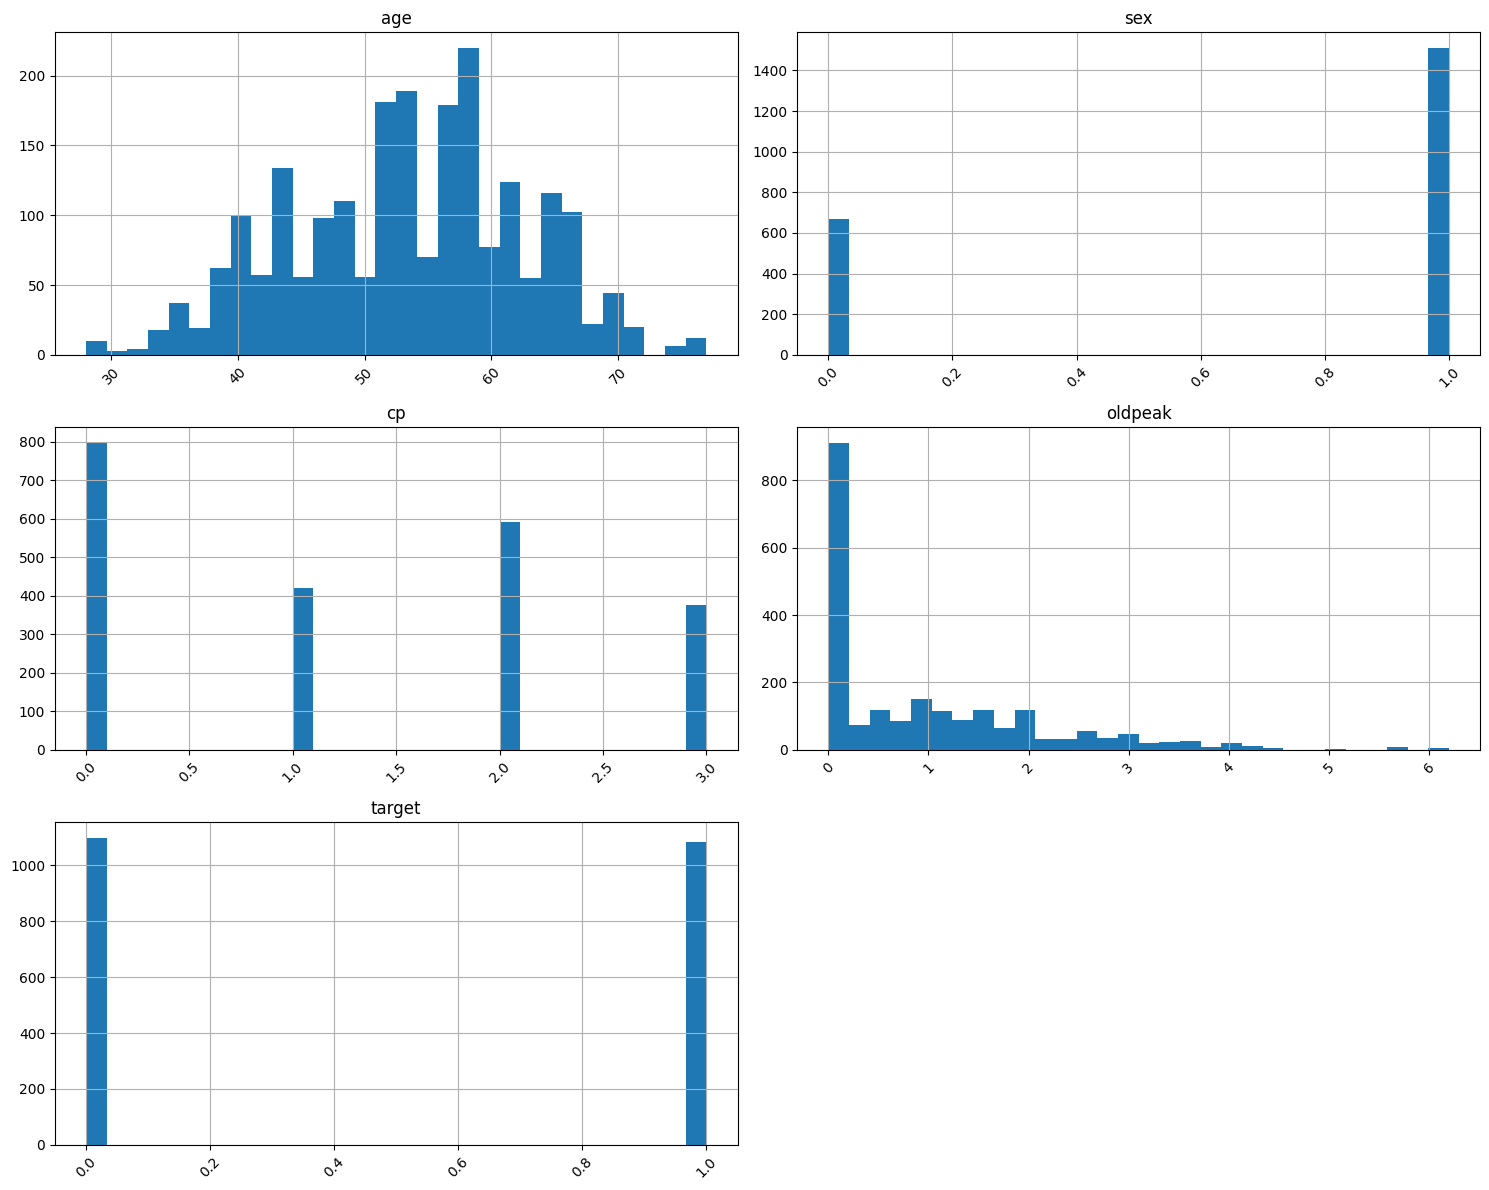

In [25]:
hists = df.hist(figsize=(15, 12), bins=30,)
for ax in hists.flatten():
  ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

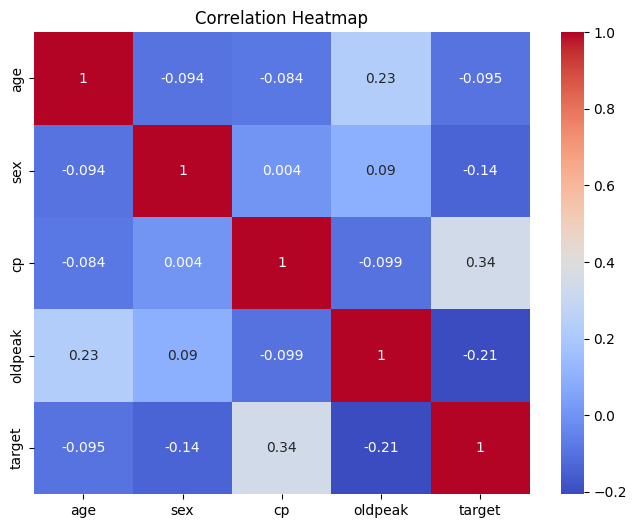

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

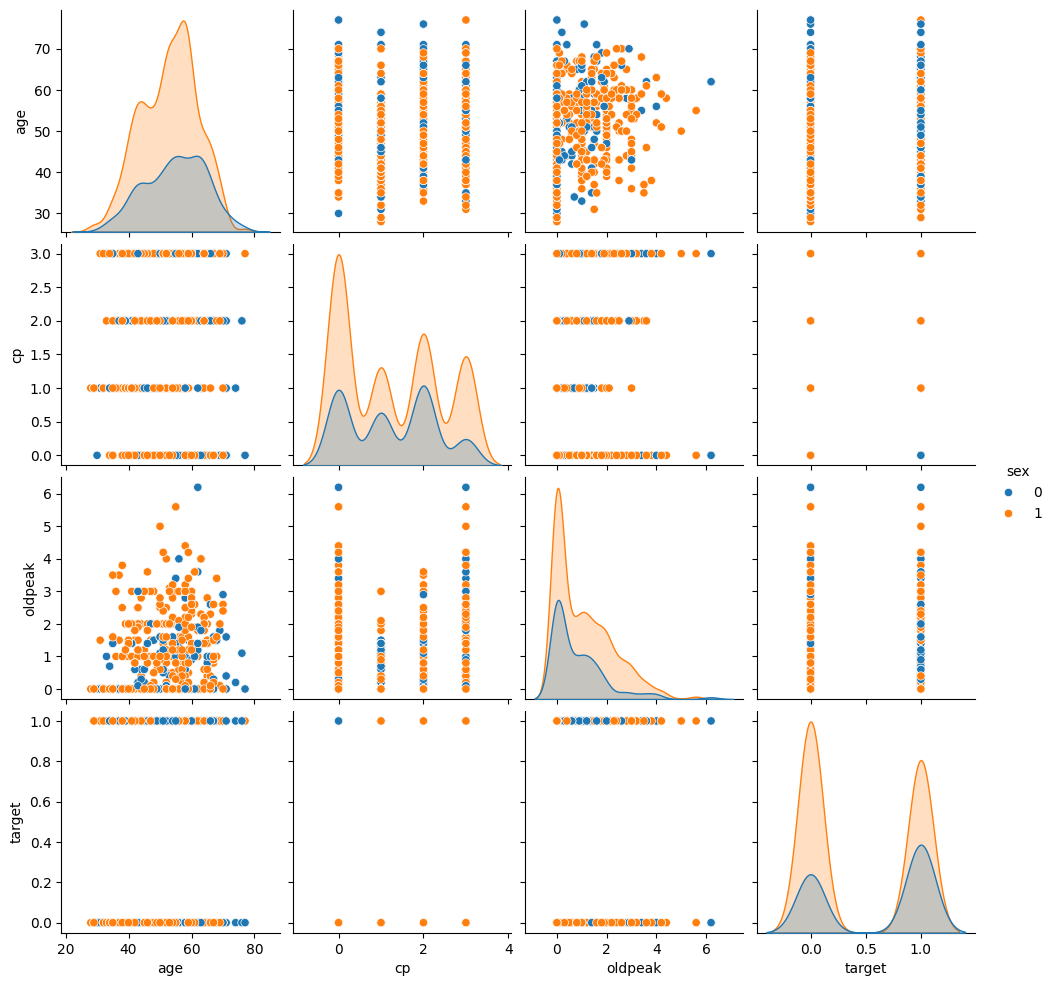

In [27]:
# This creates a grid of scatter plots for all numeric columns
sns.pairplot(df, hue='sex', diag_kind='kde')
plt.show()


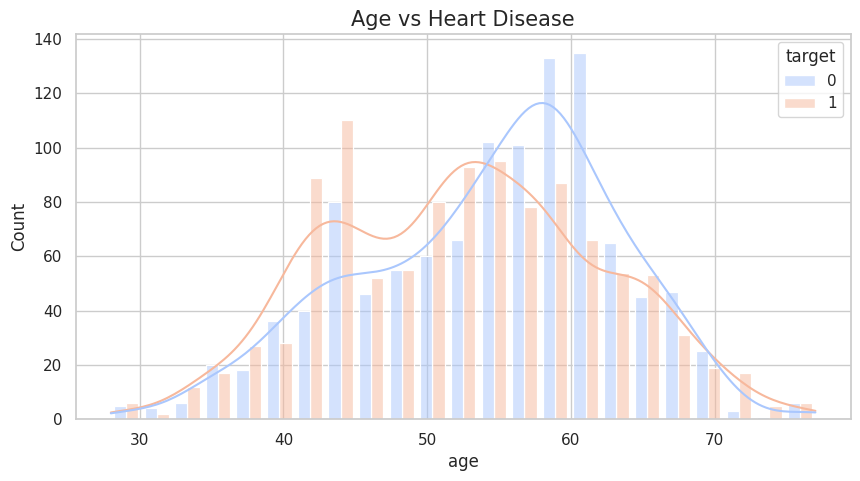

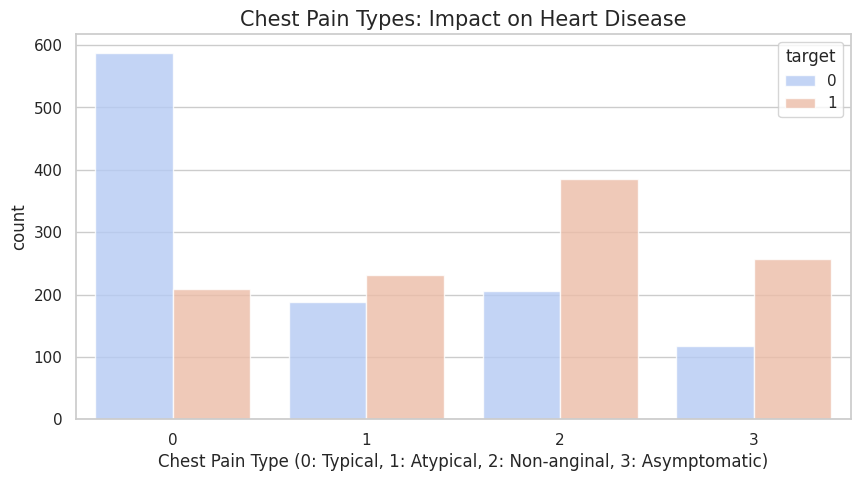

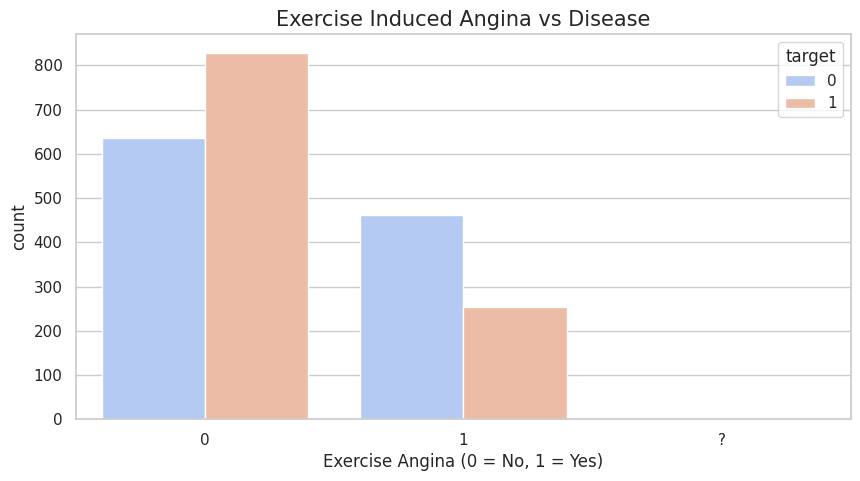

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Age Distribution (Using 'multiple="dodge"' to separate the bars)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', kde=True, multiple="dodge", shrink=.8, palette='coolwarm')
plt.title('Age vs Heart Disease', fontsize=15)
plt.show()

# 2. Chest Pain vs Disease (Focusing on the split)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='cp', hue='target', palette='coolwarm', alpha=0.8)
plt.title('Chest Pain Types: Impact on Heart Disease', fontsize=15)
plt.xlabel('Chest Pain Type (0: Typical, 1: Atypical, 2: Non-anginal, 3: Asymptomatic)')
plt.show()

# 3. Exercise Angina (Simple and clean)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='exang', hue='target', palette='coolwarm')
plt.title('Exercise Induced Angina vs Disease', fontsize=15)
plt.xlabel('Exercise Angina (0 = No, 1 = Yes)')
plt.show()

##Data Preprocessing

Handling missing values

Encoding categorical variables

Feature scaling (Decision Tree dont required one )

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2181 non-null   int64  
 1   sex       2181 non-null   int64  
 2   cp        2181 non-null   int64  
 3   trestbps  2181 non-null   object 
 4   chol      2181 non-null   object 
 5   fbs       2181 non-null   object 
 6   restecg   2181 non-null   object 
 7   thalachh  2181 non-null   object 
 8   exang     2181 non-null   object 
 9   oldpeak   2181 non-null   float64
 10  slope     2181 non-null   object 
 11  ca        2181 non-null   object 
 12  thal      2181 non-null   object 
 13  target    2181 non-null   int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 238.7+ KB


In [9]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalachh,0
exang,0
oldpeak,0


In [10]:
# Handling missing values :

# Columns that should be numeric (Data Type Conversion)
numeric_cols = ['trestbps', 'chol', 'thalachh', 'ca', 'slope', 'thal', 'fbs', 'restecg', 'exang']

# Replace '?' with NaN
df[numeric_cols] = df[numeric_cols].replace('?', np.nan)

# Convert all to numeric
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Fill NaN values
# - for numeric columns: fill with mean
for col in ['trestbps', 'chol', 'thalachh']:
    df[col] = df[col].fillna(df[col].mean())

# - for categorical columns: fill with mode
for col in ['ca', 'slope', 'thal', 'fbs', 'restecg', 'exang']:
    df[col] = df[col].fillna(df[col].mode()[0])


# Verify
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalachh    0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


#Encoding categorical variables :

Since Decision Tree is a tree-based model, it can handle categorical features represented as integers directly. Therefore, no explicit encoding (such as One-Hot Encoding) was required in this project.

#Feature scaling

Feature scaling was not applied because Decision Tree algorithms are not sensitive to feature scaling, as they rely on threshold-based splits rather than distance calculations.

## Model Implementation (Decision Tree)

Train the classification model using Scikit-learn.


In [12]:
# Define features and target
X = df.drop('target', axis=1)
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Decision Tree trained!
Tree depth       : 5
Number of leaves : 29


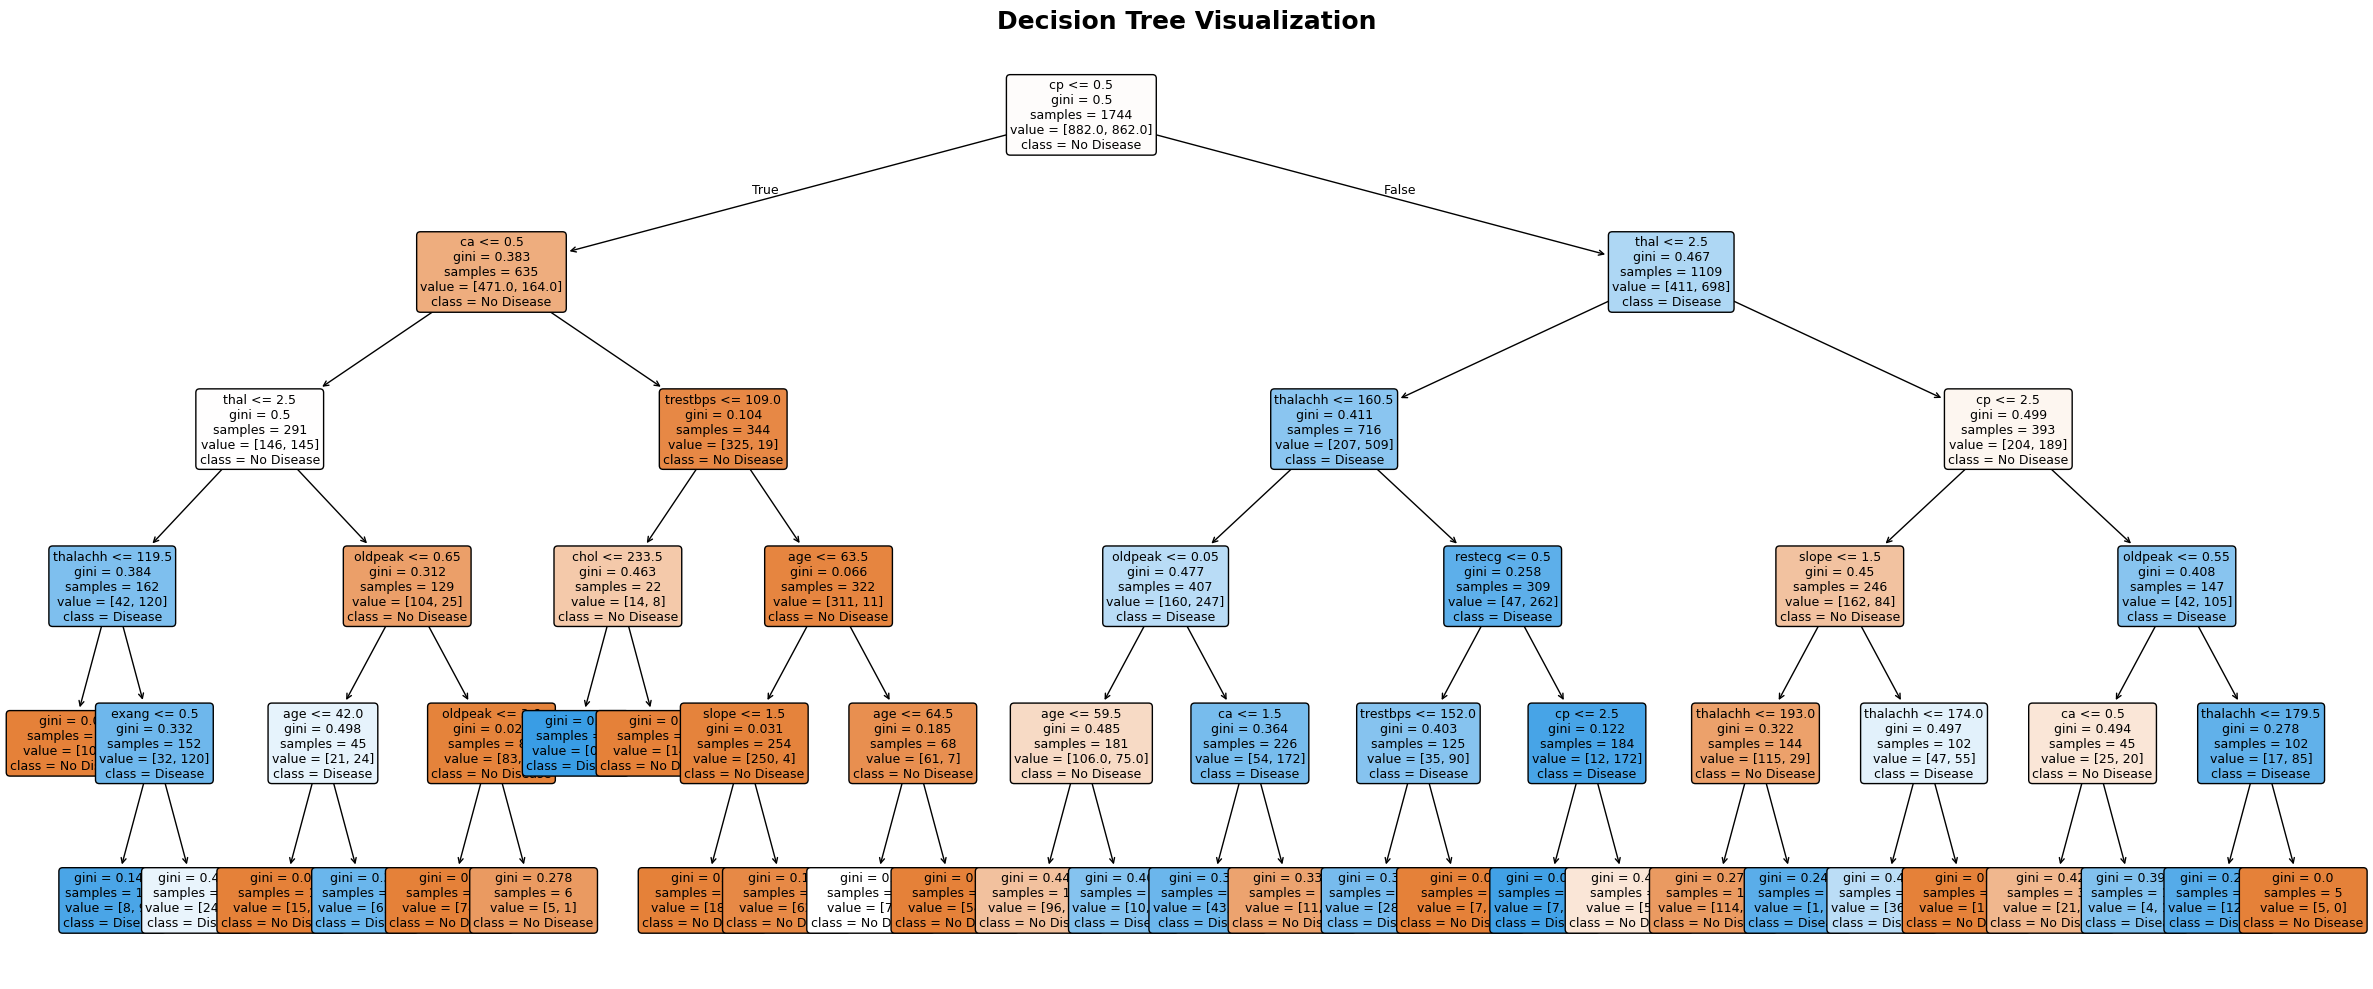

In [13]:
#Bulid Decision Tree model
dt_model = DecisionTreeClassifier(
    criterion='gini',      # Split scale : Gini = 1 - Σ(p_i)^2 / faster and give good result
    max_depth=5,           # Maximum tree depth
    min_samples_split=10,  # Minimum for the spilt
    min_samples_leaf=5,    # Minimum for each leaf
    random_state=42
) #Set max_depth, min_samples_split, min_samples_leaf to avoid overfitting.

#Train the model
dt_model.fit(X_train, y_train)
print("\nDecision Tree trained!")
print(f"Tree depth       : {dt_model.get_depth()}")
print(f"Number of leaves : {dt_model.get_n_leaves()}")


#Predictions
y_pred = dt_model.predict(X_test)


#Visualize Decision Tree
plt.figure(figsize=(24,10))
plot_tree(dt_model, feature_names=list(X.columns),
          class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree Visualization', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Evaluation

Evaluate the model using classification metrics:

Accuracy

Precision

Recall

F1 Score

Confusion Matrix

In [14]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)

In [15]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy :", acc)

prec = precision_score(y_test, y_pred)
print("Precision :", prec)

recall = recall_score(y_test, y_pred)
print("Recall :", recall)

f1 = f1_score(y_test, y_pred)
print(("F1 :", f1))

Accuracy : 0.8100686498855835
Precision : 0.801762114537445
Recall : 0.8272727272727273
('F1 :', 0.814317673378076)


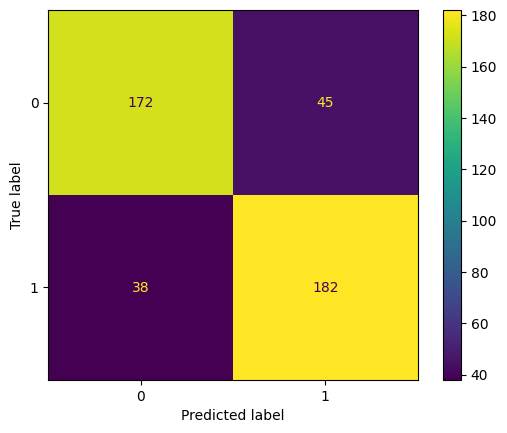

In [16]:
confusion_mat = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

## 6 Optimization

### Hyperparameter Tuning
We use GridSearchCV to find the optimal settings for the Decision Tree:

- **criterion:** The math used to determine a split (Gini for impurity vs. Entropy for information gain).


- **max_depth:** The maximum height of the tree. Limits depth to prevent overfitting.


- **min_samples_split:** Minimum data points required in a node before it can split again.


- **min_samples_leaf:** Minimum data points allowed in a final "leaf" node. Higher values smooth the model.

In [17]:
param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [3,5,7,10,None],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,5,10]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best = grid_search.best_estimator_
print(f"best parameters are: {grid_search.best_params_}")

best parameters are: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [19]:
optimized_pred=best.predict(X_test)

acc = accuracy_score(y_test, optimized_pred)
print("Accuracy :", acc)

prec = precision_score(y_test, optimized_pred)
print("Precision :", prec)

recall = recall_score(y_test, optimized_pred)
print("Recall :", recall)

f1 = f1_score(y_test, optimized_pred)
print(("F1 :", f1))

Accuracy : 0.9359267734553776
Precision : 0.9173913043478261
Recall : 0.9590909090909091
('F1 :', 0.9377777777777778)


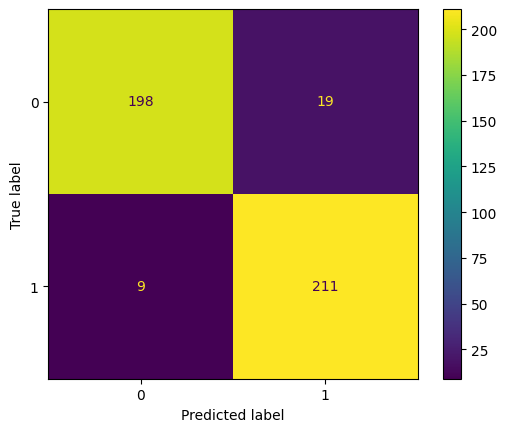

In [20]:
confusion_mat = confusion_matrix(y_test, optimized_pred)

ConfusionMatrixDisplay.from_predictions(y_test, optimized_pred)